# Análise de Dados de Viagens – 2025

## 1. Introdução

Este projeto tem como objetivo analisar os dados de viagens de 2025, utilizando Python, SQL e PostgreSQL.

Os dados foram organizados seguindo a arquitetura Medallion, dividida nas camadas RAW, SILVER e GOLD.

## 2. Objetivos

- Analisar os dados de viagens.
- Identificar padrões nos gastos com viagens.
- Comparar os valores por órgão e tipo de pagamento.
- Criar gráficos para visualizar os resultados.

## 3. Ferramentas utilizadas

- Python
- Pandas
- PostgreSQL
- SQLAlchemy
- Matplotlib
- Seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text
from banco import engine

print("Conexão com o PostgreSQL configurada!")

Conexão com o PostgreSQL configurada!


,nome_orgao_superior,quantidade_viagens
0,Ministério da Justiça e Segurança Pública,75742
1,Ministério da Educação,65295
2,Ministério da Defesa,61912
3,Ministério do Meio Ambiente e Mudança do Clima,19413
4,Ministério do Planejamento e Orçamento,18172
5,Sem informação,14768
6,Ministério da Fazenda,11854
7,Ministério da Saúde,8672
8,Ministério do Desenvolvimento Agrário e Agricu...,8581
9,Ministério da Previdência Social,8190


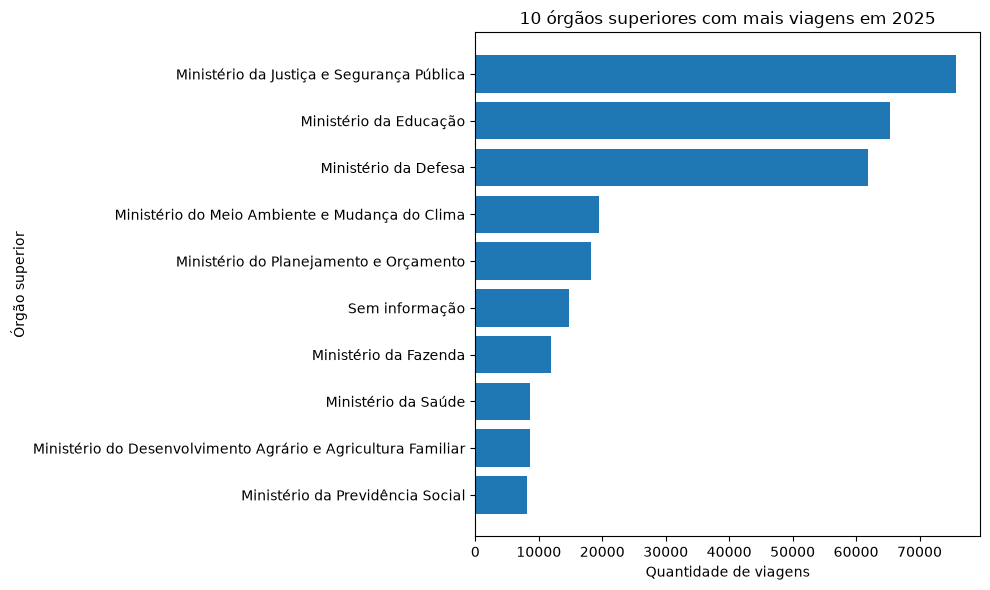

In [2]:
consulta = text("""
    SELECT
        nome_orgao_superior,
        COUNT(*) AS quantidade_viagens
    FROM silver.viagem
    WHERE nome_orgao_superior IS NOT NULL
    GROUP BY nome_orgao_superior
    ORDER BY quantidade_viagens DESC
    LIMIT 10
""")

df_viagens = pd.read_sql(consulta, engine)

display(df_viagens)

plt.figure(figsize=(10, 6))
plt.barh(
    df_viagens["nome_orgao_superior"][::-1],
    df_viagens["quantidade_viagens"][::-1]
)

plt.title("10 órgãos superiores com mais viagens em 2025")
plt.xlabel("Quantidade de viagens")
plt.ylabel("Órgão superior")
plt.tight_layout()
plt.show()

,tipo_pagamento,valor_total
0,DIÁRIAS,8.343526e+08
1,PASSAGEM,3.549789e+08
2,RESTITUIÇÃO,2.843762e+06
3,Serviço correlato: seguro,2.190137e+06


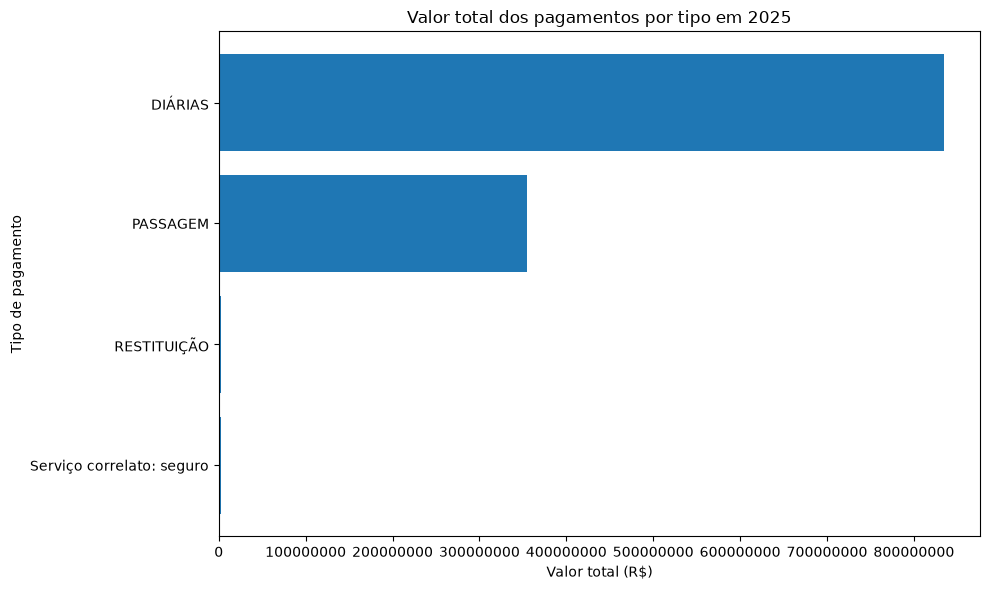

In [3]:
consulta_pagamentos = text("""
    SELECT
        tipo_pagamento,
        SUM(valor) AS valor_total
    FROM silver.pagamento
    WHERE valor IS NOT NULL
    GROUP BY tipo_pagamento
    ORDER BY valor_total DESC
""")

df_pagamentos = pd.read_sql(consulta_pagamentos, engine)

display(df_pagamentos)

plt.figure(figsize=(10, 6))

plt.barh(
    df_pagamentos["tipo_pagamento"][::-1],
    df_pagamentos["valor_total"][::-1]
)

plt.title("Valor total dos pagamentos por tipo em 2025")
plt.xlabel("Valor total (R$)")
plt.ylabel("Tipo de pagamento")
plt.ticklabel_format(axis="x", style="plain")
plt.tight_layout()
plt.show()

,mes,quantidade_viagens
0,1,26866
1,2,44808
2,3,63949
3,4,61391
4,5,73372
5,6,71474


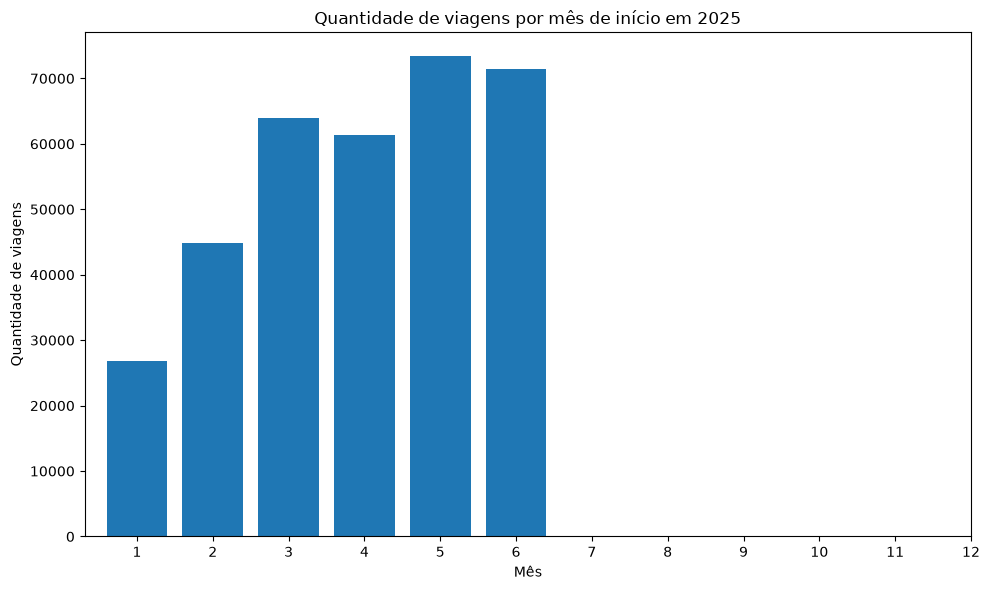

In [4]:
consulta_mensal = text("""
    SELECT
        EXTRACT(MONTH FROM data_inicio)::int AS mes,
        COUNT(*) AS quantidade_viagens
    FROM silver.viagem
    WHERE data_inicio IS NOT NULL
    GROUP BY EXTRACT(MONTH FROM data_inicio)
    ORDER BY mes
""")

df_mensal = pd.read_sql(consulta_mensal, engine)

display(df_mensal)

plt.figure(figsize=(10, 6))

plt.bar(
    df_mensal["mes"],
    df_mensal["quantidade_viagens"]
)

plt.title("Quantidade de viagens por mês de início em 2025")
plt.xlabel("Mês")
plt.ylabel("Quantidade de viagens")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

,mes,quantidade_viagens,mes_nome
0,1,26866,Jan
1,2,44808,Fev
2,3,63949,Mar
3,4,61391,Abr
4,5,73372,Mai
5,6,71474,Jun


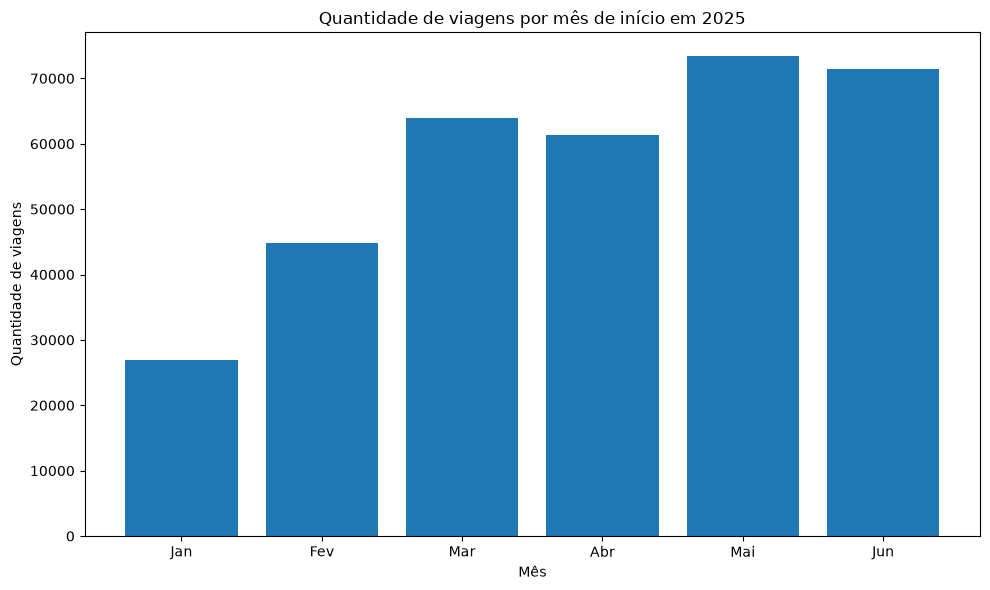

In [5]:
consulta_mensal = text("""
    SELECT
        EXTRACT(MONTH FROM data_inicio)::int AS mes,
        COUNT(*) AS quantidade_viagens
    FROM silver.viagem
    WHERE data_inicio IS NOT NULL
    GROUP BY EXTRACT(MONTH FROM data_inicio)
    ORDER BY mes
""")

df_mensal = pd.read_sql(consulta_mensal, engine)

meses = {
    1: "Jan", 2: "Fev", 3: "Mar",
    4: "Abr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Set",
    10: "Out", 11: "Nov", 12: "Dez"
}

df_mensal["mes_nome"] = df_mensal["mes"].map(meses)

display(df_mensal)

plt.figure(figsize=(10, 6))
plt.bar(
    df_mensal["mes_nome"],
    df_mensal["quantidade_viagens"]
)

plt.title("Quantidade de viagens por mês de início em 2025")
plt.xlabel("Mês")
plt.ylabel("Quantidade de viagens")
plt.tight_layout()
plt.show()

In [6]:
consulta_periodo = text("""
    SELECT
        MIN(data_inicio) AS primeira_data,
        MAX(data_inicio) AS ultima_data,
        COUNT(DISTINCT EXTRACT(MONTH FROM data_inicio))
            AS meses_com_dados
    FROM silver.viagem
    WHERE data_inicio IS NOT NULL
""")

df_periodo = pd.read_sql(consulta_periodo, engine)
display(df_periodo)

,primeira_data,ultima_data,meses_com_dados
0,2025-01-01,2025-06-30,6


## 4. Conclusão

A análise dos dados de viagens do primeiro semestre de 2025 permitiu identificar padrões na distribuição das viagens e nos gastos registrados.

O Ministério da Justiça e Segurança Pública apresentou a maior quantidade de viagens entre os órgãos superiores analisados, seguido pelo Ministério da Educação e pelo Ministério da Defesa.

Na análise dos pagamentos, as diárias representaram a maior parcela dos valores, seguidas pelas passagens.

A análise mensal mostrou variações na quantidade de viagens, com crescimento entre janeiro e março e maior volume em maio.

As análises foram realizadas utilizando Python, SQL e PostgreSQL, com visualizações desenvolvidas por meio das bibliotecas Matplotlib e Seaborn.

### Limitações

Os dados analisados abrangem o período de janeiro a junho de 2025. Portanto, os resultados não representam o ano completo e não devem ser generalizados para os meses restantes.